In [8]:
import sys
sys.path.append("..")
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.svi as svi
import src.config as config
importlib.reload(svi)

smiles = pd.read_csv(f"../data/spy_smiles_{config.SNAPSHOT_DATE}.csv", parse_dates=["expiry"])
svi_params = svi.fit_svi_surface(smiles)

pd.set_option("display.width", 200)
print(svi_params.round(4).to_string())

       expiry       T       a       b     rho       m   sigma  rmse_vol_pts  n_points
0  2026-10-13  0.0192 -0.0026  0.0273 -0.0759  0.0011  0.1018        0.2774        97
1  2026-10-14  0.0219 -0.0040  0.0321 -0.1662 -0.0095  0.1334        0.1827        98
2  2026-10-15  0.0247 -0.0034  0.0313 -0.2028 -0.0118  0.1182        0.2061        89
3  2026-10-16  0.0274 -0.0083  0.0481 -0.0297  0.0094  0.1788        0.2105       139
4  2026-10-23  0.0466 -0.0168  0.0689  0.0317  0.0316  0.2515        0.1893       152
5  2026-10-30  0.0658 -0.0182  0.0734 -0.0126  0.0297  0.2586        0.1397       239
6  2026-11-06  0.0849 -0.0183  0.0754 -0.0697  0.0230  0.2583        0.0599       155
7  2026-11-13  0.1041 -0.0172  0.0750 -0.1264  0.0156  0.2489        0.0525       144
8  2026-11-20  0.1233 -0.0327  0.1022  0.0009  0.0571  0.3360        0.2318       197
9  2026-11-30  0.1507 -0.0224  0.0884 -0.1199  0.0266  0.2765        0.0496       276
10 2026-12-18  0.2000 -0.0702  0.1557  0.0999  0.1297 

C:\Users\rious\AppData\Local\Temp\ipykernel_5388\1435714350.py:15: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(svi_params.round(4).to_string())


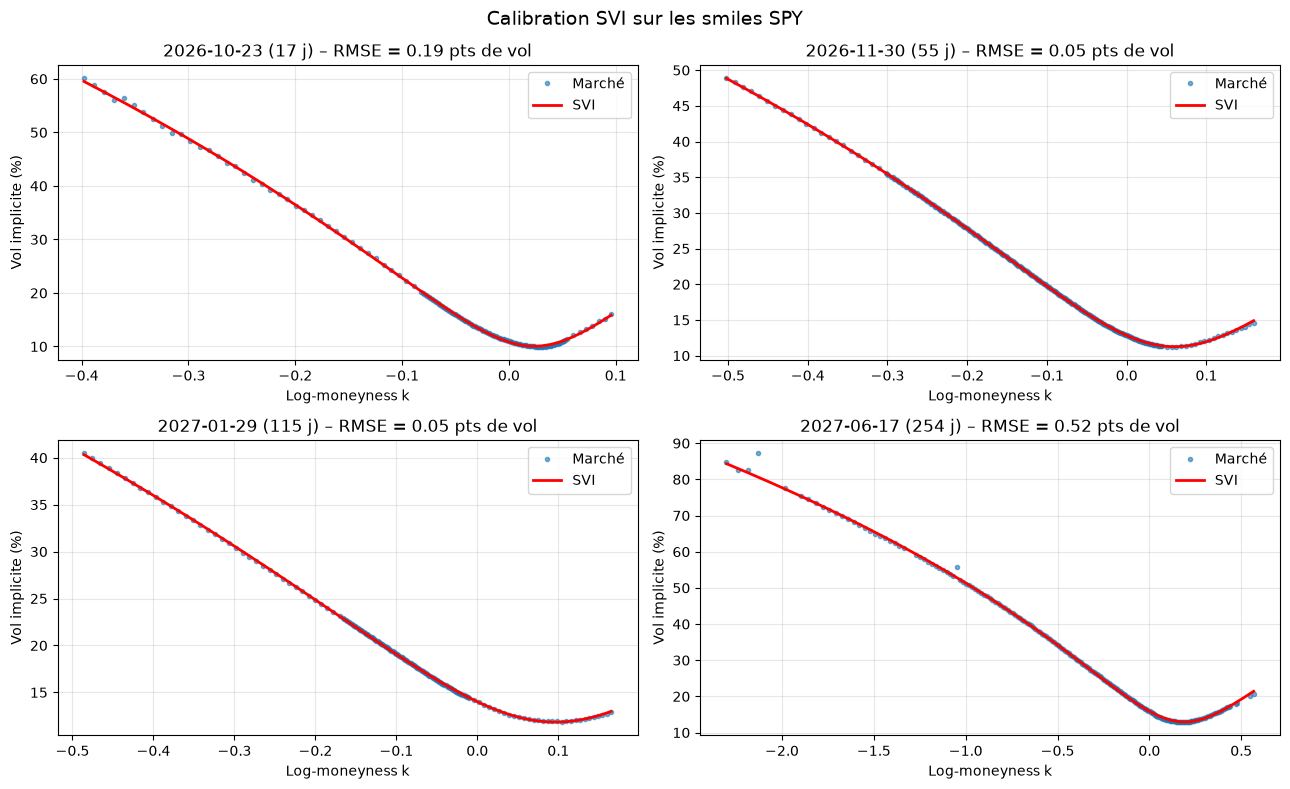

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, days in zip(axes.flat, [17, 55, 115, 254]):
    row = svi_params.iloc[(svi_params["T"] - days / 365).abs().argmin()]
    s = smiles[smiles["expiry"] == row["expiry"]]
    params = row[["a", "b", "rho", "m", "sigma"]].values.astype(float)
    k_fine = np.linspace(s["k"].min(), s["k"].max(), 300)

    ax.plot(s["k"], s["iv"] * 100, "o", ms=3, alpha=0.6, label="Marché")
    ax.plot(k_fine, svi.svi_implied_vol(k_fine, row["T"], params) * 100, "r-", lw=2, label="SVI")
    ax.set_title(f"{row['expiry'].date()} ({row['T'] * 365:.0f} j) – RMSE = {row['rmse_vol_pts']:.2f} pts de vol")
    ax.set_xlabel("Log-moneyness k")
    ax.set_ylabel("Vol implicite (%)")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle("Calibration SVI sur les smiles SPY", fontsize=14)
fig.tight_layout()
fig.savefig("../figures/svi_fit.png", dpi=150, bbox_inches="tight")
plt.show()

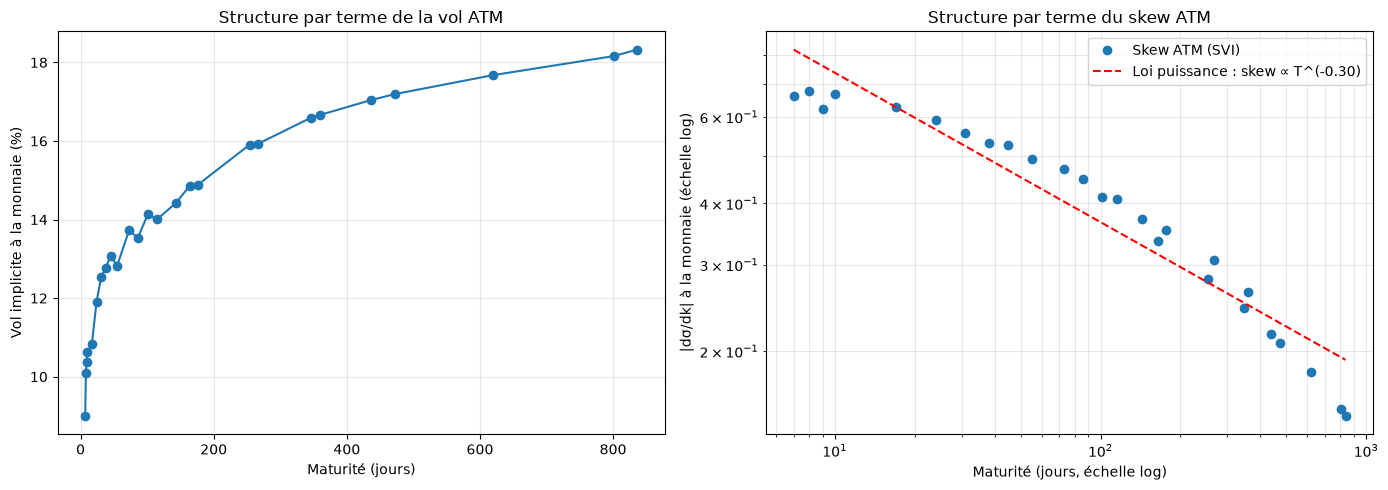

Exposant de la loi puissance du skew : -0.30
Exposant (maturités ≥ 30 jours) : -0.40


In [10]:
# Vol et skew à la monnaie, calculés à partir de SVI pour chaque maturité
h = 0.01
rows = []
for _, row in svi_params.iterrows():
    p = row[["a", "b", "rho", "m", "sigma"]].values.astype(float)
    T = row["T"]
    vol_atm = svi.svi_implied_vol(0.0, T, p)
    skew_atm = (svi.svi_implied_vol(h, T, p) - svi.svi_implied_vol(-h, T, p)) / (2 * h)
    rows.append({"T": T, "atm_vol": vol_atm, "atm_skew": skew_atm})
atm = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Structure par terme de la vol ATM
ax1.plot(atm["T"] * 365, atm["atm_vol"] * 100, "o-")
ax1.set_xlabel("Maturité (jours)")
ax1.set_ylabel("Vol implicite à la monnaie (%)")
ax1.set_title("Structure par terme de la vol ATM")
ax1.grid(alpha=0.3)

# Structure par terme du skew ATM, en échelle log-log, avec ajustement d'une loi puissance
neg = atm[atm["atm_skew"] < 0]
slope, intercept = np.polyfit(np.log(neg["T"]), np.log(-neg["atm_skew"]), 1)
ax2.loglog(neg["T"] * 365, -neg["atm_skew"], "o", label="Skew ATM (SVI)")
ax2.loglog(neg["T"] * 365, np.exp(intercept) * neg["T"] ** slope, "r--",
           label=f"Loi puissance : skew ∝ T^({slope:.2f})")
ax2.set_xlabel("Maturité (jours, échelle log)")
ax2.set_ylabel("|dσ/dk| à la monnaie (échelle log)")
ax2.set_title("Structure par terme du skew ATM")
ax2.legend()
ax2.grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("../figures/atm_term_structure.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Exposant de la loi puissance du skew : {slope:.2f}")
long = neg[neg["T"] >= 30 / 365]
slope_long, _ = np.polyfit(np.log(long["T"]), np.log(-long["atm_skew"]), 1)
print(f"Exposant (maturités ≥ 30 jours) : {slope_long:.2f}")

In [11]:
svi_params.to_csv(f"../data/svi_params_{config.SNAPSHOT_DATE}.csv", index=False)
print("Paramètres SVI sauvegardés")

Paramètres SVI sauvegardés
